In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/processed/epiclim_preprocessed.csv")
df['year_month'] = pd.to_datetime(df['year_month'])

In [3]:
district_df = df.groupby(['district', 'Latitude', 'Longitude'], as_index=False).agg(
    total_cases  = ('Cases',            'sum'),
    mean_cases   = ('Cases',            'mean'),
    max_cases    = ('Cases',            'max'),
    mean_growth  = ('Case_Growth_Rate', 'mean'),
    mean_temp    = ('Temp',             'mean'),
    mean_preci   = ('preci',            'mean'),
    mean_LAI     = ('LAI',              'mean'),
    months_active= ('Cases',            'count')
)

In [4]:
district_df['log_total_cases'] = np.log1p(district_df['total_cases'])
district_df['log_mean_cases']  = np.log1p(district_df['mean_cases'])

cluster_features = ['log_total_cases', 'log_mean_cases', 'mean_growth',
                    'mean_temp', 'mean_preci', 'mean_LAI',
                    'Latitude', 'Longitude']

X = district_df[cluster_features].fillna(0)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

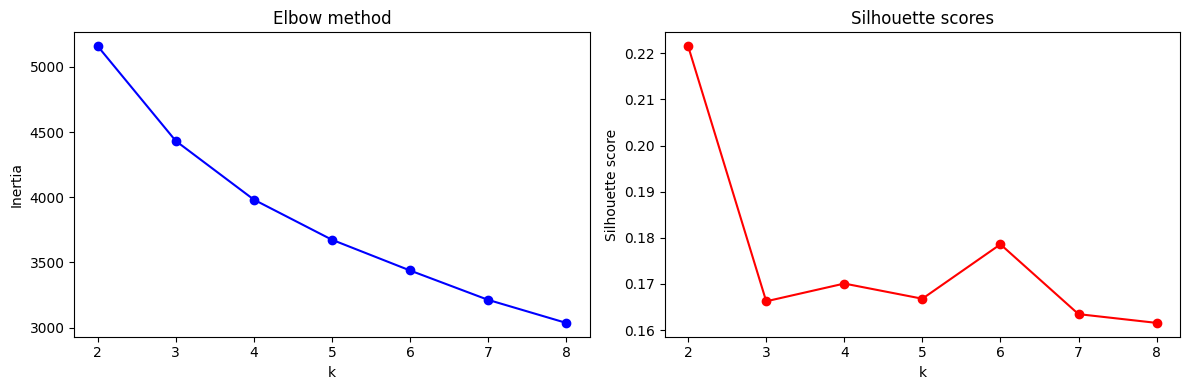

Best k by silhouette: 2


In [6]:
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')

axes[1].plot(list(K_range), sil_scores, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette scores')
plt.tight_layout()
plt.savefig("../outputs/kmeans_elbow.png", dpi=150)
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Best k by silhouette: {best_k}")



In [7]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
district_df['Cluster'] = kmeans.fit_predict(X_scaled)


In [9]:
cluster_means = district_df.groupby('Cluster')['log_total_cases'].mean().sort_values()
n = len(cluster_means)
risk_map = {}
for i, (cluster_id, _) in enumerate(cluster_means.items()):
    if i < n // 3:
        risk_map[cluster_id] = 'Low Risk'
    elif i < 2 * n // 3:
        risk_map[cluster_id] = 'Medium Risk'
    else:
        risk_map[cluster_id] = 'High Risk'

district_df['Risk_Level'] = district_df['Cluster'].map(risk_map)

print("\nCluster distribution:")
print(district_df['Risk_Level'].value_counts())



Cluster distribution:
Risk_Level
High Risk      536
Medium Risk    259
Name: count, dtype: int64


In [11]:
print("\nMean cases per risk level:")
print(district_df.groupby('Risk_Level')['total_cases'].mean().sort_values(ascending=False))


Mean cases per risk level:
Risk_Level
High Risk      847.706269
Medium Risk    317.354595
Name: total_cases, dtype: float64


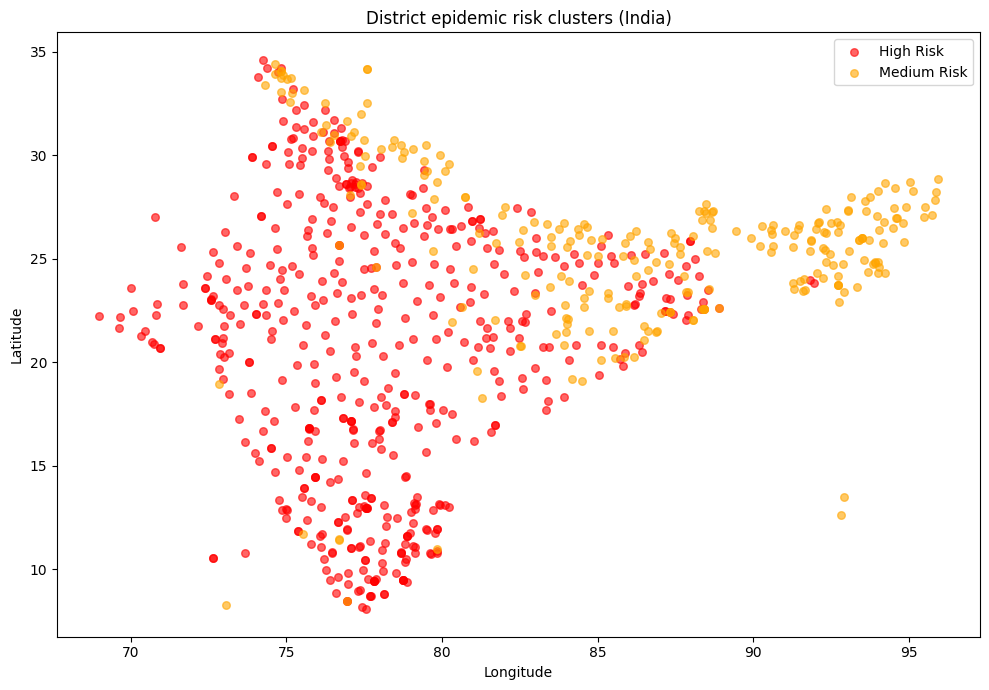

In [18]:
color_map = {'High Risk': 'red', 'Medium Risk': 'orange', 'Low Risk': 'green'}
plt.figure(figsize=(10, 7))
for level, grp in district_df.groupby('Risk_Level'):
    plt.scatter(grp['Longitude'], grp['Latitude'],
                c=color_map[level], label=level, alpha=0.6, s=30)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('District epidemic risk clusters (India)')
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/hotspot_map.png", dpi=150)
plt.show()